# Does de-censoring hurt Slovene skills more? (RQ3 capability control)

This notebook demos artifact **`art_Q-LED_B1t1VK`** (iter-3, experiment 12). The artifact measures what an
**English-objective Heretic abliteration edit** (refusal-direction removal, stored as a LoRA) costs in *capability*,
in English vs Slovene. It runs the same code path on two sibling 12B models: **GaMS3-12B-Instruct** (Slovene
continued pre-training of Gemma 3) and **Gemma-3-12B-IT**, both in NF4.

**Conditions compared on identical, row-paired EN/SL items** (6 zero-shot lm-eval tasks: ARC-C, BoolQ, HellaSwag, OBQA, PIQA, Winogrande):
* `orig`: the unedited model;
* `E_iter1`: the iter-1 selected Heretic edit (λ = 1);
* `E_art2`: artifact 2's B′ Heretic selection;
* `rand_nm_j*`: **norm-matched random-direction edits**, built by Heretic's own `abliterate()` with identical parameters (only the directions are random). This control separates "the refusal direction hurts X" from "any perturbation of this size hurts X".

**Primary statistic:** the headroom-normalised change `H = (acc_cond − chance)/(acc_orig − chance) − 1`. It is
macro-averaged over tasks with headroom ≥ 0.10, with a joint paired bootstrap. Also reported: `A = H_SL − H_EN`
(does Slovene lose more?), the interaction `I = A_GaMS − A_Gemma`, and a **catastrophe gate**
(macro loss > 0.20 ⇒ CATASTROPHIC).

**What runs here and what doesn't.** The original `method.py` only *orchestrates* resumable scripts under `src/`.
The heavy steps (loading two 12B models, building LoRA edits, running lm-eval) took about 4 h on an L4 GPU. The
notebook keeps `method.py`'s orchestration code verbatim, but in **dry-run** mode it only prints the commands. It
then **runs the real analysis step** (`src/analyze.py`: `build_vectors` → `util_block` → `gates_from`, copied
unchanged) on the per-item correctness the GPU steps saved. The input is a curated subset of **8 row-paired items
per task × 6 tasks × EN/SL = 96 items**. With only 8 items per cell the numbers are **very noisy**. The final cell
compares them with the full-run reference values (300 pairs per task), which are stored in the same JSON.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install (method.py / analyze.py log through it)
_pip('loguru==0.7.3')

# numpy, scipy, matplotlib, pandas — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'pandas==2.2.2')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports
The first block is `method.py`'s import block, unchanged. The second block holds the imports of `src/analyze.py`
and `src/common.py`, whose analysis functions run below, plus matplotlib/pandas for the results cell.

In [2]:
# --- method.py imports (original) ---
from __future__ import annotations

import argparse
import subprocess
import sys
import time
from pathlib import Path

from loguru import logger

# --- src/analyze.py + src/common.py imports (original) ---
import json
import math
from collections import defaultdict

import numpy as np
from scipy.stats import binomtest

# --- notebook-only: results table / plot ---
import pandas as pd
import matplotlib.pyplot as plt

## Data loading
`mini_demo_data.json` holds the 96 curated items. Each has `item_id`, `pair_id` (shared by the EN and SL version of
an item), `task`, `lang`, `n_choices` (so chance is `1/n_choices`), a truncated `input`, and
`correct[model][cond] ∈ {0,1}` under the task's primary lm-eval metric (acc_norm for ARC-C/HellaSwag/OBQA/PIQA,
acc for BoolQ/Winogrande). It also stores `full_run_reference`: the gates, macros and interaction from the full
300-pair run.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-2cf2a7-does-slovene-taught-refusal-survive/main/round-3/experiment-12/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(len(data["examples"]), "items;", data["description"])
print(pd.Series([(e["task"], e["lang"]) for e in data["examples"]]).value_counts().sort_index().to_string())

96 items; 96 row-paired EN/SL utility items (8 pairs x 6 tasks) with per-item correctness (primary lm-eval metric) for every model x condition; plus full-run reference macros/gates.
(arc_challenge, en)    8
(arc_challenge, sl)    8
(boolq, en)            8
(boolq, sl)            8
(hellaswag, en)        8
(hellaswag, sl)        8
(openbookqa, en)       8
(openbookqa, sl)       8
(piqa, en)             8
(piqa, sl)             8
(winogrande, en)       8
(winogrande, sl)       8


## Config
All tunable parameters live here. Values from the original run are given in comments.
* `N_BOOT`: paired-bootstrap draws (original `common.N_BOOT = 2000`).
* `N_PAIRS_PER_TASK`: pairs used per task (the original used 300; the demo file holds 8, the most the ≤100-item demo budget allows).
* `HEADROOM_FLOOR`, `GATE_LOSS`, `SEED`: frozen protocol constants from `src/common.py` (do not change them to reproduce the protocol).
* `STEPS`, `MINUTES_PER_MODEL`, `N_GEN`: `method.py`'s CLI arguments. `DRY_RUN=True` prints the GPU pipeline commands instead of running them.

In [5]:
N_BOOT = 2000               # original: 2000
N_PAIRS_PER_TASK = 8        # original: 300 (demo file contains 8 pairs/task)
HEADROOM_FLOOR = 0.10       # frozen protocol constant
GATE_LOSS = 0.20            # frozen protocol constant
SEED = 20260925             # frozen protocol constant (analyze.py bootstraps with SEED + 1)

# method.py CLI arguments (defaults as in the original argparse)
STEPS = "prep,mt,protocol,gams,gemma,analyze"
MINUTES_PER_MODEL = 100.0
N_GEN = 100
DRY_RUN = True              # the real steps need src/*.py, two 12B checkpoints and a GPU (~4 h on one L4)

## Step 0: the original orchestrator (`method.py`)
`method.py` runs each resumable step script in order: data prep → NLLB MT of the harmless set → protocol freeze
(sha256 + git commit **before** any edited-condition forward pass) → a GPU block per model (edit construction,
manipulation check, lm-eval utility, KL, generations, Belebele, BPB, second-path scorer, chat-template check) →
analysis/audit/tables/figures.

The code is unchanged except for three things:
1. The file log sink is commented out (there is no `logs/` directory in the notebook).
2. `argparse` is parsed from the config cell instead of the command line.
3. `run()` only logs the command when `DRY_RUN` is on.

In [6]:
WS = Path(".").resolve()                       # original: Path(__file__).resolve().parent
PY = str(WS / ".venv" / "bin" / "python")
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# logger.add(str(WS / "logs" / "method.log"), rotation="30 MB", level="DEBUG")   # original file sink

GPU_STAGES = "util,kl,gen,belebele,bpb,scorer2,chat"


def run(args: list[str]) -> None:
    logger.info("RUN " + " ".join(args))
    if DRY_RUN:                                # notebook-only: GPU pipeline is not executed here
        return
    t = time.time()
    r = subprocess.run([PY] + args, cwd=WS)
    logger.info(f"exit {r.returncode} after {time.time() - t:.0f}s")
    if r.returncode != 0:
        raise RuntimeError(f"step failed: {args}")


@logger.catch(reraise=True)
def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--steps", default="prep,mt,protocol,gams,gemma,analyze")
    ap.add_argument("--minutes-per-model", type=float, default=100.0)
    ap.add_argument("--n-gen", type=int, default=100)
    a = ap.parse_args(["--steps", STEPS, "--minutes-per-model", str(MINUTES_PER_MODEL), "--n-gen", str(N_GEN)])
    steps = a.steps.split(",")
    if "prep" in steps:
        run(["src/prep_data.py"])
    if "mt" in steps:
        run(["src/prep_mt.py"])
    if "protocol" in steps:
        run(["src/write_protocol.py"])
    for m, key in (("gams3_it", "gams"), ("gemma_it", "gemma")):  # GaMS first (artifact 2's Gemma selection gets more time)
        if key in steps:
            dl = int(time.time() + a.minutes_per_model * 60)
            run(["src/gpu_block.py", "--model", m, "--stages", "pilot," + GPU_STAGES, "--n-gen", str(a.n_gen),
                 "--n-gen-lambda", "50", "--util-bs", "8",
                 "--lambda-conds", "orig,E_iter1,E_iter1_l2.0,E_iter1_l1.5,E_iter1_l0.5", "--deadline-epoch", str(dl)])
    if "analyze" in steps:
        for s in ("src/analyze.py", "src/audit.py", "src/assemble_p0.py", "src/build_outputs.py", "src/make_figs.py"):
            run([s])


main()

09:32:59|INFO   |RUN src/prep_data.py


09:32:59|INFO   |RUN src/prep_mt.py


09:32:59|INFO   |RUN src/write_protocol.py


09:32:59|INFO   |RUN src/gpu_block.py --model gams3_it --stages pilot,util,kl,gen,belebele,bpb,scorer2,chat --n-gen 100 --n-gen-lambda 50 --util-bs 8 --lambda-conds orig,E_iter1,E_iter1_l2.0,E_iter1_l1.5,E_iter1_l0.5 --deadline-epoch 1790334779


09:32:59|INFO   |RUN src/gpu_block.py --model gemma_it --stages pilot,util,kl,gen,belebele,bpb,scorer2,chat --n-gen 100 --n-gen-lambda 50 --util-bs 8 --lambda-conds orig,E_iter1,E_iter1_l2.0,E_iter1_l1.5,E_iter1_l0.5 --deadline-epoch 1790334779


09:32:59|INFO   |RUN src/analyze.py


09:32:59|INFO   |RUN src/audit.py


09:32:59|INFO   |RUN src/assemble_p0.py


09:32:59|INFO   |RUN src/build_outputs.py


09:32:59|INFO   |RUN src/make_figs.py


## Step 6 setup: shared constants and helpers (`src/common.py`)
These are the protocol constants and the two definitions the whole study rests on, copied verbatim:
* `headroom_H`: the change in accuracy *as a fraction of the model's headroom above chance*, so tasks near chance
  don't dominate. `H = −0.1` means the edit lost 10% of the original headroom.
* `gate_verdict`: **CATASTROPHIC** if the point loss exceeds 0.20. **POSSIBLY_CATASTROPHIC** if only the 95% upper
  bound exceeds it. Otherwise OK.

In [7]:
MODELS = {
    "gams3_it": {"repo": "cjvt/GaMS3-12B-Instruct", "revision": "1d0b27af5748784482600d24779409e7e1dc9adc"},
    "gemma_it": {"repo": "google/gemma-3-12b-it", "revision": "96b6f1eccf38110c56df3a15bffe176da04bfd80"},
}

UTIL_TASKS = ["arc_challenge", "boolq", "hellaswag", "openbookqa", "piqa", "winogrande"]
# lm-eval convention: acc_norm for ARC-C/HellaSwag/OBQA/PIQA; acc for BoolQ/Winogrande/Belebele
PRIMARY_METRIC = {"arc_challenge": "acc_norm", "hellaswag": "acc_norm", "openbookqa": "acc_norm", "piqa": "acc_norm",
                  "boolq": "acc", "winogrande": "acc", "belebele": "acc"}
LANGS_UTIL = ["en", "sl"]


def headroom_H(acc_cond: float, acc_orig: float, chance: float) -> float:
    """Headroom-normalised delta: (acc_cond - chance)/(acc_orig - chance) - 1. Loss = -H."""
    den = acc_orig - chance
    if abs(den) < 1e-12:
        return float("nan")
    return (acc_cond - chance) / den - 1.0


def gate_verdict(loss_point: float, loss_hi95: float, threshold: float = GATE_LOSS) -> str:
    """CATASTROPHIC if point loss > threshold; POSSIBLY_CATASTROPHIC if only the 95% upper bound exceeds it."""
    if loss_point is None or (isinstance(loss_point, float) and math.isnan(loss_point)):
        return "PENDING"
    if loss_point > threshold:
        return "CATASTROPHIC"
    if loss_hi95 > threshold:
        return "POSSIBLY_CATASTROPHIC"
    return "OK"


RNG_SEED = SEED + 1
MODEL_LIST = list(MODELS)


def pct(a: np.ndarray, q: float) -> float:
    return float(np.percentile(a, q))


def ci(a: np.ndarray, level: int = 95) -> list[float]:
    lo = (100 - level) / 2
    return [round(pct(a, lo), 5), round(pct(a, 100 - lo), 5)]

## Step 6a: load per-item utility results (`load_util`, `item_order`)
In the original, `load_util` reads `results/items/util_*.jsonl`, the raw per-item lm-eval outputs, and `item_order`
reads the item files under `data/util/`. The only change here is the data source: both functions read the loaded
`data` variable instead. The returned structure is the same, `U[model][cond][(lang, task)][item_id] = (correct,
chance, pair_id)`. EN and SL rows share one `pair_id` order, so the bootstrap can resample the *same pairs* in both
languages and both models.

In [8]:
EXAMPLES = [e for e in data["examples"]]
# keep the first N_PAIRS_PER_TASK pairs per task (the demo file has 8)
_keep = {}
for e in EXAMPLES:
    _keep.setdefault(e["task"], [])
    if e["pair_id"] not in _keep[e["task"]] and len(_keep[e["task"]]) < N_PAIRS_PER_TASK:
        _keep[e["task"]].append(e["pair_id"])
EXAMPLES = [e for e in EXAMPLES if e["pair_id"] in _keep[e["task"]]]


def load_util(kind: str) -> dict:
    """-> U[model][cond][lang][task] = {item_id: correct(primary metric)}"""
    U: dict = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))
    for r in EXAMPLES:                                       # original: rows of results/items/{kind}_*.jsonl
        for model, cc in r["correct"].items():
            for cond, corr in cc.items():
                U[model][cond][(r["lang"], r["task"])][r["item_id"]] = (float(corr), 1.0 / r["n_choices"],
                                                                        r.get("pair_id"))
    return U


def item_order(task: str, lang: str) -> list[str]:
    # original: ids of data/util/{task}_{lang}.jsonl in file order
    return [r["item_id"] for r in EXAMPLES if r["task"] == task and r["lang"] == lang]


U = load_util("util")
for m in U:
    print(m, "conditions:", sorted(U[m]))

gams3_it conditions: ['E_art2', 'E_iter1', 'orig', 'rand_nm_j1']
gemma_it conditions: ['E_art2', 'E_iter1', 'orig', 'rand_nm_j1', 'rand_nm_j2']


## Step 6b: aligned vectors and the joint paired bootstrap (`build_vectors`, `boot_indices`, `util_block`)
This is copied unchanged from `src/analyze.py`. For each model × condition × language × task cell it computes:
* accuracies, chance, headroom and `H` (with a bootstrap 95% CI), raw percentage-point change, and a McNemar test,
  Holm-corrected within model × condition;
* the **macro H** over *eligible* tasks (original-model headroom ≥ 0.10), and the macro loss with its 95% upper bound;
* `A = H_SL − H_EN` per model × edit. A positive `A` means Slovene is hurt *less*;
* the interaction `I = A_GaMS − A_Gemma`, which asks whether the Slovene-adapted model's Slovene suffers more;
* **random-adjusted** `H_excess = H(edit) − H(rand_nm_j1)`: the part of the damage that a size-matched random
  perturbation does *not* explain.

The bootstrap reuses the same resampled pair indices across conditions, languages and models within a task, so
every difference is a paired one. With only a few pairs per task, some cells fall below the headroom floor or come
out with NaN bootstrap draws. That is expected at this scale.

In [9]:
def build_vectors(U: dict, model: str, conds: list[str], cells: list[tuple[str, str]]) -> dict:
    """Aligned vectors over the item ids present in orig AND every cond (intersection), per (lang, task) cell.
    Paired tasks: EN/SL share pair_id -> the SAME pair order is used in both languages."""
    out = {}
    for lang, task in cells:
        if (lang, task) not in U[model].get("orig", {}):
            continue
        common = None
        for c in ["orig"] + conds:
            ids = set(U[model].get(c, {}).get((lang, task), {}).keys())
            common = ids if common is None else common & ids
        order = [i for i in item_order(task, lang) if i in common]
        if not order:
            continue
        vec = {c: np.array([U[model][c][(lang, task)][i][0] for i in order]) for c in ["orig"] + conds}
        chance = float(np.mean([U[model]["orig"][(lang, task)][i][1] for i in order]))
        out[(lang, task)] = {"ids": order, "vec": vec, "chance": chance}
    return out


def boot_indices(n: int, rng: np.random.Generator, B: int = N_BOOT) -> np.ndarray:
    return rng.integers(0, n, size=(B, n))


def util_block(U: dict, conds_all: list[str], langs: list[str], tasks: list[str], label: str, rng_seed: int) -> dict:
    """Compute H per cell, macros, A, I, H_excess with a joint paired bootstrap (same resampled pair indices across
    conditions, languages and models within a task)."""
    rng = np.random.default_rng(rng_seed)
    cells = [(l, t) for l in langs for t in tasks]
    V = {m: build_vectors(U, m, [c for c in conds_all if c in U[m]], cells) for m in MODEL_LIST if m in U}
    # shared bootstrap indices per task: need the same n across models/languages -> use pair-index intersection
    idx = {}
    for t in tasks:
        ns = [len(V[m][(l, t)]["ids"]) for m in V for l in langs if (l, t) in V[m]]
        if not ns:
            continue
        if len(set(ns)) != 1:
            logger.warning(f"{label}/{t}: unequal n across cells {ns}; bootstrap per-cell independent for this task")
            idx[t] = None
        else:
            idx[t] = boot_indices(ns[0], rng)
    table: dict = {}
    boots: dict = {}
    for m in V:
        conds = [c for c in conds_all if c in U[m] and c != "orig"]
        table[m] = {}
        for c in conds:
            table[m][c] = {}
            for l in langs:
                table[m][c][l] = {}
                for t in tasks:
                    cell = V[m].get((l, t))
                    if cell is None or c not in cell["vec"]:
                        continue
                    vo, vc, ch = cell["vec"]["orig"], cell["vec"][c], cell["chance"]
                    ao, ac = float(vo.mean()), float(vc.mean())
                    H = headroom_H(ac, ao, ch)
                    ix = idx.get(t) if idx.get(t) is not None else boot_indices(len(vo), rng)
                    bo, bc = vo[ix].mean(1), vc[ix].mean(1)
                    with np.errstate(divide="ignore", invalid="ignore"):
                        bH = (bc - ch) / (bo - ch) - 1
                    b_ = int(((vo == 1) & (vc == 0)).sum())
                    c_ = int(((vo == 0) & (vc == 1)).sum())
                    p_mc = float(binomtest(min(b_, c_), b_ + c_, 0.5).pvalue) if b_ + c_ > 0 else 1.0
                    table[m][c][l][t] = {"acc_orig": round(ao, 5), "acc": round(ac, 5), "acc_metric": PRIMARY_METRIC[t],
                                         "chance": round(ch, 5), "headroom": round(ao - ch, 5), "H": round(H, 5),
                                         "H_ci95": ci(bH[np.isfinite(bH)]), "raw_pp": round(100 * (ac - ao), 3),
                                         "rel_pct": round(100 * (ac / ao - 1), 3) if ao > 0 else None, "n": len(vo),
                                         "eligible": bool(ao - ch >= HEADROOM_FLOOR - 1e-9), "mcnemar_b_orig_right_cond_wrong": b_,
                                         "mcnemar_c_orig_wrong_cond_right": c_, "mcnemar_p": p_mc}
                    boots[(m, c, l, t)] = (bH, (bc - bo) * 100)
                # Holm within condition happens after all langs
            # Holm-correct McNemar within model x condition
            ps = [(l, t, table[m][c][l][t]["mcnemar_p"]) for l in table[m][c] for t in table[m][c][l]]
            order = sorted(range(len(ps)), key=lambda k: ps[k][2])
            running = 0.0
            for rank, k in enumerate(order):
                adj = min(1.0, (len(ps) - rank) * ps[k][2])
                running = max(running, adj)
                l, t, _ = ps[k]
                table[m][c][l][t]["mcnemar_p_holm"] = round(running, 6)
    # macros
    macros: dict = {}
    macro_boot: dict = {}
    RAW_H: dict = {}
    for m in table:
        macros[m] = {}
        for c in table[m]:
            macros[m][c] = {}
            for l in langs:
                cells_l = table[m][c].get(l, {})
                if not cells_l:
                    continue
                elig = [t for t in cells_l if cells_l[t]["eligible"]]
                inel = [t for t in cells_l if not cells_l[t]["eligible"]]
                Hm = float(np.mean([cells_l[t]["H"] for t in elig])) if elig else float("nan")
                bHm = np.mean([boots[(m, c, l, t)][0] for t in elig], axis=0) if elig else np.full(N_BOOT, np.nan)
                raw = float(np.mean([cells_l[t]["raw_pp"] for t in cells_l]))
                braw = np.mean([boots[(m, c, l, t)][1] for t in cells_l], axis=0)
                rel = float(np.mean([cells_l[t]["rel_pct"] for t in cells_l if cells_l[t]["rel_pct"] is not None]))
                macro_boot[(m, c, l)] = (bHm, braw)
                RAW_H[(m, c, l)] = Hm
                macros[m][c][l] = {"macro_H": round(Hm, 5), "macro_H_ci95": ci(bHm[np.isfinite(bHm)]) if elig else None,
                                   "macro_H_ci90": ci(bHm[np.isfinite(bHm)], 90) if elig else None,
                                   "macro_loss": round(-Hm, 5), "macro_loss_hi95": round(-pct(bHm[np.isfinite(bHm)], 2.5), 5) if elig else None,
                                   "eligible_tasks": elig, "ineligible_tasks": inel, "raw_pp_macro": round(raw, 4),
                                   "raw_pp_macro_ci95": ci(braw), "rel_pct_macro": round(rel, 4),
                                   "F6_raw_pp_rule": len(inel) >= 3}
            if all(l in macros[m][c] for l in ("en", "sl")) and len(langs) >= 2:
                pooled = (macro_boot[(m, c, "en")][0] + macro_boot[(m, c, "sl")][0]) / 2
                A = macro_boot[(m, c, "sl")][0] - macro_boot[(m, c, "en")][0]
                macros[m][c]["pooled_macro_H"] = round((RAW_H[(m, c, "en")] + RAW_H[(m, c, "sl")]) / 2, 5)
                macros[m][c]["pooled_macro_H_ci95"] = ci(pooled[np.isfinite(pooled)])
                macros[m][c]["A_sl_minus_en"] = round(RAW_H[(m, c, "sl")] - RAW_H[(m, c, "en")], 5)
                macros[m][c]["A_ci95"] = ci(A[np.isfinite(A)])
                macros[m][c]["A_ci90"] = ci(A[np.isfinite(A)], 90)
    # interaction and random-adjusted
    inter: dict = {}
    if len(macros) == 2:
        mg, mm = "gams3_it", "gemma_it"
        for c in set(macros.get(mg, {})) & set(macros.get(mm, {})):
            if "A_sl_minus_en" in macros[mg][c] and "A_sl_minus_en" in macros[mm][c]:
                bA = {m: macro_boot[(m, c, "sl")][0] - macro_boot[(m, c, "en")][0] for m in (mg, mm)}
                bI = bA[mg] - bA[mm]
                inter[c] = {"I": round((RAW_H[(mg, c, "sl")] - RAW_H[(mg, c, "en")]) - (RAW_H[(mm, c, "sl")] - RAW_H[(mm, c, "en")]), 5),
                            "I_ci95": ci(bI[np.isfinite(bI)]), "I_ci90": ci(bI[np.isfinite(bI)], 90),
                            "note": "resolution limit ~0.10-0.12 of headroom (80% power, alpha .05); |I| below it is an estimate, not 'no asymmetry'"}
    excess: dict = {}
    for m in macros:
        for c in macros[m]:
            if c.startswith("E_") and "rand_nm_j1" in macros[m]:
                excess.setdefault(m, {})[c] = {}
                for l in langs:
                    if l in macros[m][c] and l in macros[m]["rand_nm_j1"]:
                        b = macro_boot[(m, c, l)][0] - macro_boot[(m, "rand_nm_j1", l)][0]
                        excess[m][c][l] = {"H_excess": round(RAW_H[(m, c, l)] - RAW_H[(m, "rand_nm_j1", l)], 5),
                                           "ci95": ci(b[np.isfinite(b)])}
                if "en" in excess[m][c] and "sl" in excess[m][c]:
                    bA = (macro_boot[(m, c, "sl")][0] - macro_boot[(m, c, "en")][0]) - \
                         (macro_boot[(m, "rand_nm_j1", "sl")][0] - macro_boot[(m, "rand_nm_j1", "en")][0])
                    excess[m][c]["A_excess"] = {"value": round((RAW_H[(m, c, "sl")] - RAW_H[(m, "rand_nm_j1", "sl")]) - (RAW_H[(m, c, "en")] - RAW_H[(m, "rand_nm_j1", "en")]), 5),
                                                "ci95": ci(bA[np.isfinite(bA)])}
    return {"cells": table, "macros": macros, "interaction": inter, "random_adjusted": excess,
            "_macro_boot": macro_boot}


conds_all = ["orig", "E_iter1", "E_art2", "rand_nm_j1", "rand_nm_j2"]
util = util_block(U, conds_all, LANGS_UTIL, UTIL_TASKS, "util", RNG_SEED)
print("interaction I:", {c: (v["I"], v["I_ci95"]) for c, v in util["interaction"].items()})

interaction I: {'E_iter1': (0.08333, [-0.25, 0.33333]), 'E_art2': (0.25, [-0.19965, 0.61875]), 'rand_nm_j1': (-0.05556, [-0.16667, 0.0])}


/tmp/ipykernel_1190/2711541015.py:110: RuntimeWarning: invalid value encountered in add
  pooled = (macro_boot[(m, c, "en")][0] + macro_boot[(m, c, "sl")][0]) / 2
/tmp/ipykernel_1190/2711541015.py:135: RuntimeWarning: invalid value encountered in subtract
  b = macro_boot[(m, c, l)][0] - macro_boot[(m, "rand_nm_j1", l)][0]


## Step 6c: the catastrophe gate (`gates_from`)
Copied unchanged. For each model × condition × language, the gate applies the headroom-macro rule (loss > 0.20).
If three or more tasks are ineligible (headroom below the floor), it falls back to the F6 raw-pp rule (5 pp). The
verdict for the condition is the worst verdict across languages. The raw-pp verdict is always co-reported as a
sensitivity check. (In the original run the λ-subset block is passed as the second argument; here it is `None`.)

In [10]:
def gates_from(util: dict, lam: dict | None) -> dict:
    g: dict = {}
    for src, blk in (("full", util), ("lambda_subset", lam)):
        if not blk:
            continue
        for m, cc in blk["macros"].items():
            for c, d in cc.items():
                langs = [l for l in ("en", "sl") if l in d]
                verdicts = {}
                for l in langs:
                    x = d[l]
                    if x["F6_raw_pp_rule"]:
                        loss = -x["raw_pp_macro"]
                        hi = -x["raw_pp_macro_ci95"][0]
                        verdicts[l] = {"rule": "F6 raw-pp (5 pp)", "loss": loss, "loss_hi95": hi, "verdict": gate_verdict(loss, hi, 5.0)}
                    else:
                        verdicts[l] = {"rule": "headroom macro (0.20)", "loss": x["macro_loss"], "loss_hi95": x["macro_loss_hi95"],
                                       "verdict": gate_verdict(x["macro_loss"], x["macro_loss_hi95"] if x["macro_loss_hi95"] is not None else float("nan"))}
                    # co-reported sensitivity (decides nothing on its own): raw-pp macro loss vs the F6 5-pp threshold
                    verdicts[l]["sensitivity_raw_pp"] = {"loss_pp": -x["raw_pp_macro"], "loss_pp_hi95": -x["raw_pp_macro_ci95"][0],
                                                         "verdict_5pp": gate_verdict(-x["raw_pp_macro"], -x["raw_pp_macro_ci95"][0], 5.0)}
                rank = {"OK": 0, "POSSIBLY_CATASTROPHIC": 1, "CATASTROPHIC": 2, "PENDING": -1}
                worst = max((v["verdict"] for v in verdicts.values()), key=lambda s: rank[s]) if verdicts else "PENDING"
                if c in g.get(m, {}) and g[m][c]["source"] == "full":
                    g[m][c]["lambda_subset_check"] = {"per_lang": verdicts, "verdict": worst}  # full-set gate takes precedence
                    continue
                g.setdefault(m, {})[c] = {"source": src, "per_lang": verdicts, "verdict": worst}
    return g


gates = gates_from(util, None)
for m in gates:
    print(m, {c: gates[m][c]["verdict"] for c in gates[m]})

gams3_it {'E_iter1': 'POSSIBLY_CATASTROPHIC', 'E_art2': 'CATASTROPHIC', 'rand_nm_j1': 'OK'}
gemma_it {'E_iter1': 'OK', 'E_art2': 'OK', 'rand_nm_j1': 'OK', 'rand_nm_j2': 'OK'}


## Results: demo subset vs full run
The table puts the demo's macro H per language, `A = H_SL − H_EN` and the gate verdict next to the **full-run
reference** (300 pairs per task, stored in `full_run_reference`). The plots show:
* **left:** per-task `H` for the E_iter1 edit, EN vs SL, both models, on the demo subset;
* **right:** `A` for each edit and the random control, demo vs full run. The full run's headline finding is that
  `A > 0` in all four model × edit cells, i.e. Slovene is **not** hurt more than English.

With 8 pairs per task, a single flipped item moves a task's accuracy by 12.5 pp. Expect the demo's numbers to
differ from the full run and to have very wide CIs. The point of the demo is the pipeline, not these estimates. For example, on these 8 pairs the GaMS `E_art2` gate can come out `CATASTROPHIC`, and Gemma shows no flipped item at all (every H = 0), while the full-run verdict is `OK` for every E_iter1/E_art2 condition.

**Check of the code path:** these same cells, run on all 300 pairs per task from the artifact's `full_method_out.json`
with `N_BOOT = 2000`, reproduce the artifact's reported macros, `A`, `I` and their bootstrap 95% CIs *exactly*
(e.g. `I(E_iter1) = +0.010 [−0.065, 0.074]`). Every number in the "full" columns can therefore be regenerated by this
notebook given the full item file.

   model       cond  H_en demo  H_en full  H_sl demo  H_sl full   A demo         A demo CI95   A full             gate demo gate full
gams3_it    E_iter1   -0.13889   -0.01800   -0.05556    0.00653  0.08333 [-0.16667, 0.33333]  0.02453 POSSIBLY_CATASTROPHIC        OK
gams3_it     E_art2   -0.22222   -0.01988    0.02778   -0.00885  0.25000 [-0.16667, 0.60903]  0.01104          CATASTROPHIC        OK
gams3_it rand_nm_j1    0.00000   -0.00343   -0.05556   -0.03003 -0.05556     [-0.16667, 0.0] -0.02660                    OK        OK
gemma_it    E_iter1    0.00000    0.00772    0.00000    0.02180  0.00000          [0.0, 0.0]  0.01408                    OK        OK
gemma_it     E_art2    0.00000    0.01634    0.00000    0.04908  0.00000          [0.0, 0.0]  0.03275                    OK        OK
gemma_it rand_nm_j1    0.00000    0.00852    0.00000    0.00157  0.00000          [0.0, 0.0] -0.00695                    OK        OK
gemma_it rand_nm_j2    0.00000   -0.00672    0.00000   -0.0075

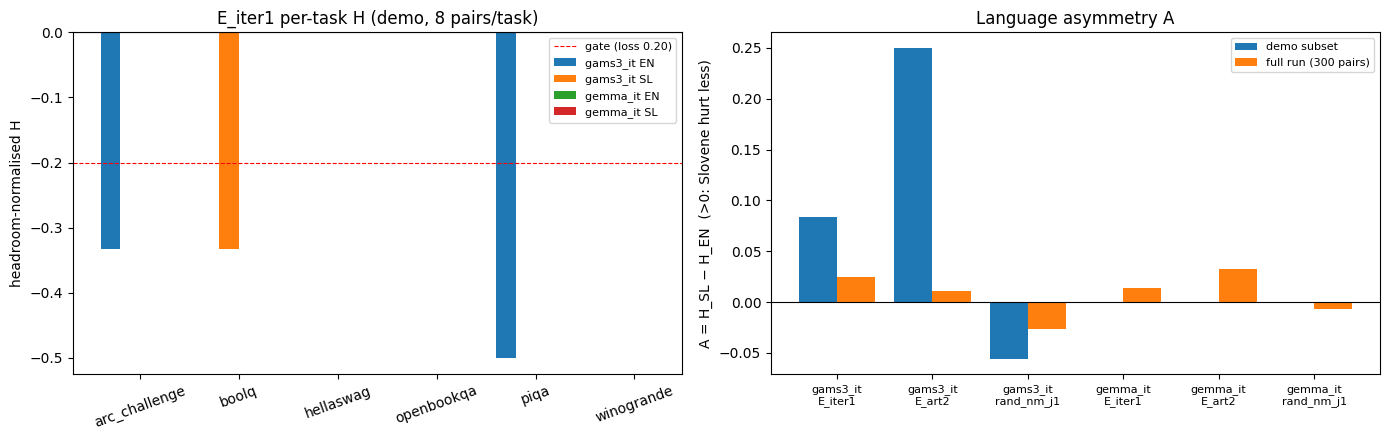

In [11]:
REF = data["full_run_reference"]
rows = []
for m in util["macros"]:
    for c in util["macros"][m]:
        d, r = util["macros"][m][c], REF["macros"].get(m, {}).get(c, {})
        rows.append({"model": m, "cond": c,
                     "H_en demo": d.get("en", {}).get("macro_H"), "H_en full": r.get("en", {}).get("macro_H"),
                     "H_sl demo": d.get("sl", {}).get("macro_H"), "H_sl full": r.get("sl", {}).get("macro_H"),
                     "A demo": d.get("A_sl_minus_en"), "A demo CI95": d.get("A_ci95"), "A full": r.get("A_sl_minus_en"),
                     "gate demo": gates[m][c]["verdict"], "gate full": REF["gates"].get(m, {}).get(c)})
res = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print(res.to_string(index=False))
print("\nInteraction I = A_GaMS - A_Gemma")
for c, v in util["interaction"].items():
    rf = REF["interaction"].get(c, {})
    print(f"  {c:12s} demo I={v['I']:+.3f} CI95={v['I_ci95']}   full I={rf.get('I', float('nan')):+.3f} CI95={rf.get('I_ci95')}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
x = np.arange(len(UTIL_TASKS)); w = 0.2
for k, (m, l) in enumerate([(m, l) for m in MODEL_LIST for l in LANGS_UTIL]):
    cells = util["cells"][m]["E_iter1"][l]
    ax.bar(x + (k - 1.5) * w, [cells[t]["H"] if t in cells else np.nan for t in UTIL_TASKS], w, label=f"{m} {l.upper()}")
ax.axhline(0, color="k", lw=0.8); ax.axhline(-GATE_LOSS, color="r", ls="--", lw=0.8, label="gate (loss 0.20)")
ax.set_xticks(x); ax.set_xticklabels(UTIL_TASKS, rotation=20); ax.set_ylabel("headroom-normalised H")
ax.set_title(f"E_iter1 per-task H (demo, {N_PAIRS_PER_TASK} pairs/task)"); ax.legend(fontsize=8)

ax = axes[1]
labs, demo_A, full_A = [], [], []
for m in MODEL_LIST:
    for c in ["E_iter1", "E_art2", "rand_nm_j1"]:
        if c in util["macros"].get(m, {}):
            labs.append(f"{m}\n{c}")
            demo_A.append(util["macros"][m][c].get("A_sl_minus_en", np.nan))
            full_A.append(REF["macros"].get(m, {}).get(c, {}).get("A_sl_minus_en", np.nan))
x = np.arange(len(labs))
ax.bar(x - 0.2, demo_A, 0.4, label="demo subset"); ax.bar(x + 0.2, full_A, 0.4, label="full run (300 pairs)")
ax.axhline(0, color="k", lw=0.8); ax.set_xticks(x); ax.set_xticklabels(labs, fontsize=8)
ax.set_ylabel("A = H_SL − H_EN  (>0: Slovene hurt less)"); ax.set_title("Language asymmetry A"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()